# Notebook 5 — LoRA recovery on Qwen 2.5 3B (Taylor 50% pruned)

**Goal:** end-to-end test of the recovery pipeline:
1. Load Qwen 2.5 3B Instruct
2. Compute Taylor (gradient) importance on a small calibration set
3. Apply **50% uniform per-matrix** pruning on MLP tiles using Taylor scores
4. Measure MMLU → expect ~26.8% (matches notebook 4 "Fused 50% Taylor")
5. Attach LoRA adapters to MLP projections
6. Fine-tune on MMLU auxiliary-train examples, **answer-token-only loss**
7. Re-measure MMLU → does accuracy recover?

**Run 2 updates** (after the first pass underperformed):
- Calibration samples 128 → **256** (match notebook 4 exactly)
- Training samples 100 → **500**, epochs 2 → **3**
- Training loss **masked to only the answer-letter token** so 100% of the gradient signal targets what MMLU actually measures

**Design choices kept simple:**
- Masks are applied by zeroing weights in place (no forward patching). Behaves identically to the block-sparse kernel, but LoRA attaches cleanly to the underlying `nn.Linear`s.
- Fusion / block-sparse kernel is OFF in this notebook — we're testing accuracy recovery, not speed.

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

import config
from eval_mmlu import evaluate, print_results

MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
TILE_R, TILE_C = config.TILE_SIZES[0]
SPARSITY = 0.50  # uniform per-matrix, Taylor-ranked

torch.set_float32_matmul_precision("high")
print(f"torch: {torch.__version__}  device: {torch.cuda.get_device_name(0)}")
free, total = torch.cuda.mem_get_info()
print(f"GPU free: {free/1e9:.2f} / {total/1e9:.2f} GB")
assert free > 6e9, "need >6 GB free for Qwen 3B"

torch: 2.6.0+cu124  device: NVIDIA GeForce RTX 4070 Laptop GPU
GPU free: 7.56 / 8.18 GB


## 1. Load model

In [2]:
print(f"loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=getattr(torch, config.TORCH_DTYPE),
    device_map=config.DEVICE,
)
model.eval()

print(f"params: {sum(p.numel() for p in model.parameters())/1e9:.2f}B")
print(f"peak GPU: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")
print(f"layers: {model.config.num_hidden_layers}  hidden: {model.config.hidden_size}  "
      f"intermediate: {model.config.intermediate_size}")

loading Qwen/Qwen2.5-3B-Instruct...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

params: 3.09B
peak GPU: 6.17 GB
layers: 36  hidden: 2048  intermediate: 11008


## 2. Calibration data

256 C4 samples at seq_len 128 — matches notebook 4's Taylor calibration exactly.

In [3]:
N_CAL = 512       # double notebook 4 — halving this was the reason pre-LoRA MMLU was worse than 26.8%
SEQ_LEN_CAL = 128

print("loading C4 calibration stream...")
cal_ds = load_dataset(
    config.CALIBRATION_DATASET,
    config.CALIBRATION_SUBSET,
    split="train",
    streaming=True,
    trust_remote_code=True,
)
cal_texts = []
for ex in cal_ds:
    t = ex.get("text", "")
    if len(t) > 50:
        cal_texts.append(t)
    if len(cal_texts) >= N_CAL:
        break
cal_encodings = [
    tokenizer(t, return_tensors="pt", max_length=SEQ_LEN_CAL, truncation=True)
    for t in cal_texts
]
print(f"calibration samples: {len(cal_encodings)}, seq_len={SEQ_LEN_CAL}")

loading C4 calibration stream...


Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

calibration samples: 512, seq_len=128


## 3. Taylor / gradient importance

`score(tile) = Σ |w · ∂L/∂w|` — first-order Taylor approximation of loss change if the tile is zeroed.

Per-tile sums accumulate on GPU via `register_post_accumulate_grad_hook`, and each `param.grad` is freed immediately after extraction. Only way MLP gradients fit on 8 GB.

In [4]:
def is_mlp(name):
    return any(k in name for k in config.PRUNE_TARGETS_PATTERNS)

def get_component_type(name):
    for p in config.PRUNE_TARGETS_PATTERNS:
        if p in name:
            return p
    return "unknown"

for p in model.parameters():
    p.requires_grad_(False)
n_trainable = 0
for name, p in model.named_parameters():
    if is_mlp(name) and p.ndim == 2:
        p.requires_grad_(True)
        n_trainable += 1
print(f"trainable MLP matrices: {n_trainable}")

if hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable()
model.config.use_cache = False

importance_grad_gpu = {}

def make_post_grad_hook(pname):
    def hook(param):
        if param.grad is None:
            return
        taylor = (param.data * param.grad).abs().float()
        out_dim, in_dim = taylor.shape
        nr, nc = out_dim // TILE_R, in_dim // TILE_C
        tt = taylor[:nr*TILE_R, :nc*TILE_C].reshape(nr, TILE_R, nc, TILE_C).permute(0, 2, 1, 3)
        tile_scores = tt.reshape(nr, nc, -1).sum(dim=-1)
        if pname in importance_grad_gpu:
            importance_grad_gpu[pname] += tile_scores
        else:
            importance_grad_gpu[pname] = tile_scores.clone()
        param.grad = None
    return hook

hook_handles = []
for name, p in model.named_parameters():
    if is_mlp(name) and p.ndim == 2 and p.requires_grad:
        hook_handles.append(p.register_post_accumulate_grad_hook(make_post_grad_hook(name)))

print("running Taylor calibration (fwd+bwd, grad_ckpt on)...")
n_samples = 0
for enc in tqdm(cal_encodings, desc="taylor"):
    model.zero_grad(set_to_none=True)
    inputs = {k: v.to(config.DEVICE) for k, v in enc.items()}
    out = model(**inputs, labels=inputs["input_ids"])
    out.loss.backward()
    n_samples += 1

for h in hook_handles:
    h.remove()
if hasattr(model, "gradient_checkpointing_disable"):
    model.gradient_checkpointing_disable()
model.config.use_cache = True
for p in model.parameters():
    p.requires_grad_(False)

importance_grad = {name: (v / n_samples).cpu().numpy()
                   for name, v in importance_grad_gpu.items()}
del importance_grad_gpu
gc.collect(); torch.cuda.empty_cache()
print(f"Taylor scored {len(importance_grad)} matrices over {n_samples} samples")
print(f"peak GPU during calib: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

trainable MLP matrices: 108
running Taylor calibration (fwd+bwd, grad_ckpt on)...


taylor: 100%|██████████████████████████████████████████████████████| 512/512 [03:29<00:00,  2.45it/s]


Taylor scored 108 matrices over 512 samples
peak GPU during calib: 7.01 GB


## 4. Build 50% uniform Taylor-based masks

Per-component-type z-score (so `gate_proj / up_proj / down_proj` scales match), then zero the bottom 50% of each matrix individually. Matches notebook 4's "Fused 50% Taylor" config → baseline MMLU 26.8%.

In [5]:
comp_stats = {}
for ct in config.PRUNE_TARGETS_PATTERNS:
    vals = np.concatenate([m.ravel() for n, m in importance_grad.items() if ct in n])
    comp_stats[ct] = (vals.mean(), vals.std())
    print(f"  {ct}: mean={vals.mean():.4f}  std={vals.std():.4f}  tiles={len(vals)}")

importance_norm = {}
for name, m in importance_grad.items():
    mu, sd = comp_stats[get_component_type(name)]
    importance_norm[name] = (m - mu) / sd if sd > 1e-8 else np.zeros_like(m)

prune_masks = {}
for name, m in importance_norm.items():
    thr = float(np.percentile(m.ravel(), SPARSITY * 100))
    prune_masks[name] = m < thr

total = sum(m.size for m in prune_masks.values())
pruned = sum(m.sum() for m in prune_masks.values())
print(f"\neffective sparsity: {pruned}/{total} = {100*pruned/total:.1f}%")

  gate_proj: mean=0.0393  std=0.0124  tiles=49536
  up_proj: mean=0.0485  std=0.0159  tiles=49536
  down_proj: mean=0.0530  std=0.0161  tiles=49536

effective sparsity: 74304/148608 = 50.0%


## 5. Apply masks (zero weights in place)

`nn.Linear` keeps its default `F.linear` — pruned tiles are literal zeros in the weight, output is identical to the block-sparse kernel.

In [6]:
mlp_linears = {}
for name, module in model.named_modules():
    if isinstance(module, nn.Linear):
        pn = name + ".weight"
        if pn in prune_masks:
            mlp_linears[pn] = module

print(f"applying 50% Taylor masks to {len(mlp_linears)} MLP matrices...")
with torch.no_grad():
    for pname, module in mlp_linears.items():
        mask = prune_masks[pname]
        w = module.weight.data
        out_f, in_f = w.shape
        nr, nc = out_f // TILE_R, in_f // TILE_C
        for i in range(nr):
            for j in range(nc):
                if mask[i, j]:
                    w[i*TILE_R:(i+1)*TILE_R, j*TILE_C:(j+1)*TILE_C] = 0

sample_name = next(iter(mlp_linears))
sample_w = mlp_linears[sample_name].weight.data
print(f"  sample check {sample_name}: {100*(sample_w == 0).float().mean().item():.1f}% zero")

applying 50% Taylor masks to 108 MLP matrices...
  sample check model.layers.0.mlp.gate_proj.weight: 50.0% zero


## 6. MMLU evaluation — pruned, pre-LoRA

Expected: ~26.8% (per notebook 4 findings for Fused 50% Taylor on Qwen 3B).
Dense baseline on this model was 48.7%, so that's the accuracy we want to recover.

In [7]:
print("=== MMLU pre-LoRA (pruned only) ===")
t0 = time.time()
results_pre = evaluate(model, tokenizer, tag="qwen25_3b_taylor50_preLoRA")
print_results(results_pre)
mmlu_pre = results_pre["overall"]["accuracy"]
print(f"elapsed: {time.time()-t0:.1f}s   overall: {mmlu_pre*100:.2f}%")

=== MMLU pre-LoRA (pruned only) ===


[qwen25_3b_taylor50_preLoRA] MMLU subjects: 100%|████████████████████| 10/10 [01:18<00:00,  7.87s/it]


  MMLU Results — qwen25_3b_taylor50_preLoRA
  abstract_algebra               █████░░░░░░░░░░░░░░░  25.0% (25/100)
  anatomy                        ████░░░░░░░░░░░░░░░░  22.2% (30/135)
  college_chemistry              ██████░░░░░░░░░░░░░░  34.0% (34/100)
  college_computer_science       ██████░░░░░░░░░░░░░░  32.0% (32/100)
  econometrics                   ████░░░░░░░░░░░░░░░░  23.7% (27/114)
  global_facts                   ███░░░░░░░░░░░░░░░░░  19.0% (19/100)
  machine_learning               ██████░░░░░░░░░░░░░░  31.2% (35/112)
  moral_scenarios                ████░░░░░░░░░░░░░░░░  24.9% (223/895)
  professional_medicine          ██████░░░░░░░░░░░░░░  30.5% (83/272)
  us_foreign_policy              ██████░░░░░░░░░░░░░░  33.0% (33/100)
────────────────────────────────────────────────────────────
  OVERALL                                       26.7% (541/2028)

elapsed: 93.1s   overall: 26.68%


## 7. Load MMLU training examples

`cais/mmlu` has a dedicated `auxiliary_train` split (~99k examples) for MMLU fine-tuning. We grab 500 — disjoint from the `test` split the evaluator uses.

In [8]:
N_TRAIN = 500     # up from 100 — see if LoRA actually recovers anything

print("loading MMLU auxiliary_train...")
mmlu_train = load_dataset("cais/mmlu", "all", split="auxiliary_train",
                          streaming=True, trust_remote_code=True)
train_rows = []
for row in mmlu_train:
    train_rows.append(row)
    if len(train_rows) >= N_TRAIN:
        break
print(f"collected {len(train_rows)} train examples")
print("first example keys:", list(train_rows[0].keys()))

CHOICE_LABELS = ["A", "B", "C", "D"]

def format_prompt(question, choices):
    """Matches eval_mmlu.format_mmlu_prompt exactly — ends with 'Answer:' (no trailing space)."""
    lines = [question]
    for label, choice in zip(CHOICE_LABELS, choices):
        lines.append(f"{label}. {choice}")
    lines.append("Answer:")
    return "\n".join(lines)

# Use exactly the same single-token encoding the evaluator uses for A/B/C/D
# so training supervises the same token the evaluator scores against.
CHOICE_TOKEN_IDS = [tokenizer.encode(lbl, add_special_tokens=False)[-1]
                    for lbl in CHOICE_LABELS]
print("choice token ids (A/B/C/D):", CHOICE_TOKEN_IDS,
      "->", [tokenizer.decode([t]) for t in CHOICE_TOKEN_IDS])

print("\n--- sample prompt (what the model will see during eval + training) ---")
print(format_prompt(train_rows[0]["question"], train_rows[0]["choices"]))
print(f"--- expected next token: {tokenizer.decode([CHOICE_TOKEN_IDS[int(train_rows[0]['answer'])]])!r} ---")

loading MMLU auxiliary_train...
collected 500 train examples
first example keys: ['question', 'subject', 'choices', 'answer']
choice token ids (A/B/C/D): [32, 33, 34, 35] -> ['A', 'B', 'C', 'D']

--- sample prompt (what the model will see during eval + training) ---
Davis decided to kill Adams. He set out for Adams's house. Before he got there he saw Brooks, who resembled Adams. Thinking that Brooks was Adams, Davis shot at Brooks. The shot missed Brooks but wounded Case, who was some distance away. Davis had not seen Case. In a prosecution under a statute that proscribes any attempt to commit murder, the district attorney should indicate that the intended victim(s) was/were
A. Adams only.
B. Brooks only.
C. Case only.
D. Adams and Brooks
Answer:
--- expected next token: 'B' ---


## 8. Attach LoRA adapters

LoRA adds low-rank adapters `ΔW = B @ A` (`r=16`) on top of each MLP projection. Base weights stay frozen (and stay pruned — zeros stay zero). Only the small LoRA params train.

In [9]:
from peft import LoraConfig, get_peft_model, TaskType

# Run 4: r=32 + full-precision AdamW. Tests the 'higher rank would help' hypothesis
# without the AdamW8bit confound. Memory: ~45M trainable, fp optimizer state ~360 MB
# on top of r=16's 7.01 GB peak → expect ~7.2 GB peak, fits on 8 GB card.
# Compare to Run 1 (r=16 + fp AdamW): MMLU went 26.68% pre-LoRA → 25.99% post-LoRA (−0.69pp).
# If r=32 recovers more of the pruning damage, capacity was a real constraint at r=16.
lora_cfg = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["gate_proj", "up_proj", "down_proj"],  # MLP only — matches pruning scope
    lora_dropout=0.0,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)
model = get_peft_model(model, lora_cfg)

# CRITICAL for gradient checkpointing + PEFT on a frozen base model:
# the input-embedding output doesn't naturally require_grad (base is frozen),
# so checkpoint-recompute fails silently and activations get retained. This
# hook tags the embedding output so autograd treats the checkpointed regions
# correctly. Without it you OOM on seq_len=256.
model.enable_input_require_grads()

model.print_trainable_parameters()
print(f"peak GPU after LoRA attach: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

trainable params: 45,121,536 || all params: 3,131,060,224 || trainable%: 1.4411
peak GPU after LoRA attach: 7.01 GB


## 9. LoRA training — answer-token-only loss

**Key change vs the first run:** loss is masked so only the answer-letter token counts. Standard causal-LM loss averages over every token (~100-150 per sample), so the single answer token gets <1% of the gradient signal. Since MMLU scores a single log-prob at that position, we point 100% of the signal there.

Prompt construction is explicit (build prompt and full sequence separately) rather than string-splitting — robust against `A` / `B` letters appearing earlier in the text.

Batch 1, seq_len 256, gradient checkpointing. 3 epochs × 500 samples = ~1500 steps.

In [10]:
EPOCHS = 3
LR = 1e-4
MAX_LEN = 192      # down from 256 — tighter activation memory, still covers nearly all MMLU prompts
IGNORE = -100

model.train()
model.gradient_checkpointing_enable()
model.config.use_cache = False

optim = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
)

# Build batches: input = prompt_ids + [answer_token]; labels IGNORE everywhere
# except the final position (the answer token). This supervises exactly the
# same A/B/C/D token the evaluator reads, via HF's internal label-shift.
train_batches = []
skipped = 0
for row in train_rows:
    ans_idx = int(row["answer"])
    prompt = format_prompt(row["question"], row["choices"])
    prompt_ids = tokenizer(prompt, return_tensors="pt",
                           max_length=MAX_LEN - 1, truncation=True)["input_ids"][0]
    answer_tok = torch.tensor([CHOICE_TOKEN_IDS[ans_idx]], dtype=prompt_ids.dtype)
    input_ids = torch.cat([prompt_ids, answer_tok])

    if len(input_ids) > MAX_LEN:
        skipped += 1
        continue

    labels = torch.full_like(input_ids, IGNORE)
    labels[-1] = answer_tok.item()  # supervise only the final token

    train_batches.append({
        "input_ids":      input_ids.unsqueeze(0),
        "attention_mask": torch.ones_like(input_ids).unsqueeze(0),
        "labels":         labels.unsqueeze(0),
    })

n_sup = sum((b["labels"] != IGNORE).sum().item() for b in train_batches)
print(f"prepared {len(train_batches)} batches (skipped {skipped})")
print(f"supervised tokens: {n_sup} total  ({n_sup/max(len(train_batches),1):.2f} per sample)")
assert len(train_batches) > 0, "no batches prepared — check tokenization"

# Reclaim any leftover activations from the pre-LoRA eval before training
gc.collect(); torch.cuda.empty_cache()
print(f"VRAM before training: allocated {torch.cuda.memory_allocated()/1e9:.2f} GB  "
      f"reserved {torch.cuda.memory_reserved()/1e9:.2f} GB")

losses = []
t0 = time.time()
for epoch in range(EPOCHS):
    order = np.random.RandomState(42 + epoch).permutation(len(train_batches))
    pbar = tqdm(order, desc=f"epoch {epoch+1}/{EPOCHS}")
    for idx in pbar:
        b = train_batches[idx]
        out = model(
            input_ids=b["input_ids"].to(config.DEVICE),
            attention_mask=b["attention_mask"].to(config.DEVICE),
            labels=b["labels"].to(config.DEVICE),
        )
        out.loss.backward()
        optim.step()
        optim.zero_grad(set_to_none=True)
        losses.append(out.loss.item())
        if len(losses) % 20 == 0:
            pbar.set_postfix(loss=f"{np.mean(losses[-20:]):.3f}")

train_time = time.time() - t0
print(f"\ntrained {len(losses)} steps in {train_time:.1f}s ({train_time/max(len(losses),1)*1000:.0f} ms/step)")
print(f"mean loss first 20: {np.mean(losses[:20]):.3f}")
print(f"mean loss last 20:  {np.mean(losses[-20:]):.3f}")
print(f"peak GPU during training: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

model.gradient_checkpointing_disable()
model.config.use_cache = True
model.eval()

prepared 500 batches (skipped 0)
supervised tokens: 500 total  (1.00 per sample)
VRAM before training: allocated 6.41 GB  reserved 6.44 GB


epoch 3/3: 100%|███████████████████████████████████████| 500/500 [01:43<00:00,  4.84it/s, loss=1.448]


trained 1500 steps in 310.4s (207 ms/step)
mean loss first 20: 5.196
mean loss last 20:  1.448
peak GPU during training: 7.17 GB


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 2048)
        (layers): ModuleList(
          (0-35): 36 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
              (k_proj): Linear(in_features=2048, out_features=256, bias=True)
              (v_proj): Linear(in_features=2048, out_features=256, bias=True)
              (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
            )
            (mlp): Qwen2MLP(
              (gate_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=11008, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=32, bias=False)
                )
      

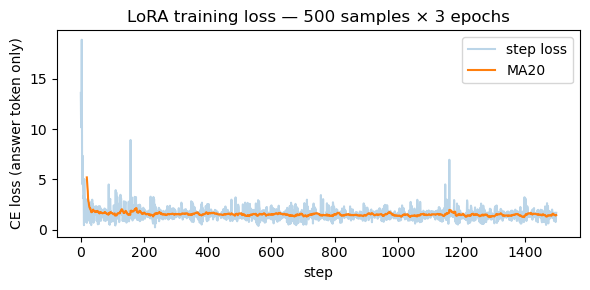

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(losses, alpha=0.3, label="step loss")
if len(losses) >= 20:
    w = 20
    smoothed = np.convolve(losses, np.ones(w)/w, mode="valid")
    ax.plot(range(w-1, len(losses)), smoothed, label=f"MA{w}")
ax.set_xlabel("step"); ax.set_ylabel("CE loss (answer token only)")
ax.legend(); ax.set_title(f"LoRA training loss — {len(train_batches)} samples × {EPOCHS} epochs")
plt.tight_layout(); plt.show()

## 10. MMLU evaluation — post-LoRA

In [12]:
print("=== MMLU post-LoRA (pruned + LoRA-trained, answer-token loss) ===")
t0 = time.time()
results_post = evaluate(model, tokenizer, tag="qwen25_3b_taylor50_postLoRA")
print_results(results_post)
mmlu_post = results_post["overall"]["accuracy"]
print(f"elapsed: {time.time()-t0:.1f}s")

=== MMLU post-LoRA (pruned + LoRA-trained, answer-token loss) ===


[qwen25_3b_taylor50_postLoRA] MMLU subjects: 100%|███████████████████| 10/10 [01:32<00:00,  9.30s/it]


  MMLU Results — qwen25_3b_taylor50_postLoRA
  abstract_algebra               ██████░░░░░░░░░░░░░░  31.0% (31/100)
  anatomy                        ██████░░░░░░░░░░░░░░  33.3% (45/135)
  college_chemistry              ███░░░░░░░░░░░░░░░░░  18.0% (18/100)
  college_computer_science       █████░░░░░░░░░░░░░░░  26.0% (26/100)
  econometrics                   ████░░░░░░░░░░░░░░░░  24.6% (28/114)
  global_facts                   ██████░░░░░░░░░░░░░░  33.0% (33/100)
  machine_learning               ████░░░░░░░░░░░░░░░░  24.1% (27/112)
  moral_scenarios                ████░░░░░░░░░░░░░░░░  24.9% (223/895)
  professional_medicine          ███░░░░░░░░░░░░░░░░░  16.5% (45/272)
  us_foreign_policy              █████░░░░░░░░░░░░░░░  26.0% (26/100)
────────────────────────────────────────────────────────────
  OVERALL                                       24.8% (502/2028)

elapsed: 105.2s


## 11. Summary

In [13]:
print("=" * 56)
print("  LoRA recovery — Qwen 2.5 3B, Taylor 50% pruned")
print("=" * 56)
print(f"  Dense baseline (reference from notebook 4):     48.70%")
print(f"  Pruned only      (Taylor 50% MLP):           {mmlu_pre*100:6.2f}%")
print(f"  + LoRA on {len(train_batches)} samples × {EPOCHS} epochs:       {mmlu_post*100:6.2f}%")
delta = (mmlu_post - mmlu_pre) * 100
sign = "+" if delta >= 0 else ""
print(f"  Δ from LoRA:                                 {sign}{delta:5.2f}pp")
print("=" * 56)
if delta > 1.0:
    print("✓ LoRA recovered signal — scale up training set / epochs next")
elif delta > 0:
    print("~ small positive movement — worth scaling up to confirm")
else:
    print("⚠ no recovery — revisit LR, target modules, or inspect loss curve")

  LoRA recovery — Qwen 2.5 3B, Taylor 50% pruned
  Dense baseline (reference from notebook 4):     48.70%
  Pruned only      (Taylor 50% MLP):            26.68%
  + LoRA on 500 samples × 3 epochs:        24.75%
  Δ from LoRA:                                 -1.93pp
⚠ no recovery — revisit LR, target modules, or inspect loss curve
